In [1]:
#recap
import numpy as np

def compute_mse(y_actual, y_predicted):
  return np.mean((np.square(y_actual - y_predicted)))

In [2]:
y_actual = np.array([3, 5, 7, 9])
y_predicted = np.array([2, 5, 8, 9])

#built-in function
compute_mse(y_actual,y_predicted)

np.float64(0.5)

In [3]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_actual,y_predicted))

0.5


In [4]:
#The 3 steps of gradient descent as comments
  #step 1: calculate prediction
      #y_predicted = m*X + b
  #step 2: Calculate gradients for both -
      # 1. ∂MSE/∂m = (-2/n) × Σ x × (y_actual - y_predicted)
      #2. ∂MSE/∂b = (-2/n) × Σ (y_actual - y_predicted)
  #update rules
    # m = m - learning rate x  ∂MSE/∂m
    # b = b - learning rate x ∂MSE/∂b

In [5]:
# df.groupby('Pclass')['Survived'].mean()
  # groupby returns Pclass as index -->(groupby.index)
  # Sruvived as values --> (groupby.values)

# Week -3 --> Day 2
1. Regularisation: Ridge (L2), Lasso (L1), ElasticNet — what each penalises and why

2. Plot coefficient paths: how Ridge vs Lasso shrink features differently
3.	Polynomial features: fit a curve, observe overfitting as degree increases


## 1.Regularisation

1. Overfitting happens when model is too well trained on training data.

2. Regularisation helps to minimise the variance and introduce bias wrt testing data, in a form of penalty. This penalty is helpful, which discourages the model from relying too heavily on any single feature or learning overly complex.


> 1. Ridge(L2) regularisation -> introduces a penalty which is equal to sum of squared coefficients(variables/features). Shrinks the coeffiecients(features) but not to zero. Very useful when aall features are needed and dependent.

> 2. Laso(L1) regularisation -> introduces a penalty which is equal to absolute value of coefficients(variables/features). Shrinks the coeffiecients(features)  to zero, thus removing unnecessary variables which may affect the model.

> 2. Elastic net regularisation ->combines L1 and L2 penalties. Useful in bigger unknown datasets where parameters are unknown and their corelation may not be known.

         

- When you keep adding features to a linear regression model, what goes wrong?
1. Overfitting
2. curse of dimensionality
3. more features than training sample, so false confidence

## 2. Plot coefficient paths: how Ridge vs Lasso shrink features differently

In [6]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.fillna({'Age': df['Age'].median()}, inplace=True)
df.dropna(subset=['Embarked'], inplace=True)
df['Title'] = df['Name'].str.extract(r', ([A-Za-z]+)\.')
df['AgeGroup'] = df['Age'].apply(lambda x: 'Child' if x<13 else 'Teen' if x<18 else 'Adult' if x<61 else 'Senior')
df['Sex_encoded'] = df['Sex'].map({'male':0, 'female':1})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
 12  Title        888 non-null    object 
 13  AgeGroup     889 non-null    object 
 14  Sex_encoded  889 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 111.1+ KB


In [7]:
#Task 1 : Implement all three with Sklearn on Titanic:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
#Use Pclass, Age, Fare, Sex_encoded to predict Survived.
#Fit all three, print coefficients. Compare which features each model shrinks.

In [8]:
features = ['Pclass', 'Age', 'Fare', 'Sex_encoded']
X = df[features]
y = df['Survived']

scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)


clf = Ridge(alpha=1.0)
clf.fit(X_scaled,y)



Ridge()

In [9]:
X_scaled

array([[ 0.82520863, -0.56367407, -0.50023975, -0.73534203],
       [-1.57221121,  0.66921696,  0.78894661,  1.35991138],
       [ 0.82520863, -0.25545131, -0.48664993,  1.35991138],
       ...,
       [ 0.82520863, -0.10133993, -0.17408416,  1.35991138],
       [-1.57221121, -0.25545131, -0.0422126 , -0.73534203],
       [ 0.82520863,  0.20688282, -0.49017322, -0.73534203]])

In [10]:
X_scaled.shape

(889, 4)

In [11]:
print("Coefficients:", clf.coef_)
print("Intercept:", clf.intercept_)  # 0.0 if fit_intercept=False
print(pd.DataFrame({'Feature': features, 'Coef': clf.coef_}).sort_values('Coef', key=abs, ascending=False))

Coefficients: [-0.1522771  -0.06496257  0.00399727  0.23714501]
Intercept: 0.38245219347581555
       Feature      Coef
3  Sex_encoded  0.237145
0       Pclass -0.152277
1          Age -0.064963
2         Fare  0.003997


In [12]:
#lasso
L1_lasso = Lasso(alpha=0.01)
L1_lasso.fit(X_scaled,y)

Lasso(alpha=0.01)

In [13]:
L1_lasso.coef_

array([-1.40773971e-01, -5.13618158e-02,  1.85018153e-04,  2.30743772e-01])

In [14]:
L1_lasso.intercept_

np.float64(0.38245219347581555)

In [15]:
#print(pd.DataFrame({"Feature:" features, "Coefficients: " L1_lasso.coef_}).sort_values("Coefficients",key = abs,ascending=True))
print(pd.DataFrame({'Feature': features, 'Coef': L1_lasso.coef_}).sort_values('Coef', key=abs, ascending=False))

       Feature      Coef
3  Sex_encoded  0.230744
0       Pclass -0.140774
1          Age -0.051362
2         Fare  0.000185


In [16]:
#elastic net
regr = ElasticNet(alpha=0.01, l1_ratio= 0.5)
regr.fit(X_scaled,y)

ElasticNet(alpha=0.01)

In [17]:
regr.coef_

array([-0.14546876, -0.05770567,  0.00279283,  0.23296117])

In [18]:
regr.intercept_

np.float64(0.38245219347581555)

In [19]:
print(pd.DataFrame({"Features":  features, "Coef": regr.coef_}).sort_values("Coef", key=abs, ascending=False))


      Features      Coef
3  Sex_encoded  0.232961
0       Pclass -0.145469
1          Age -0.057706
2         Fare  0.002793


## Multicollinearity. --> Lasso
1. Two features carrying redundant information, and Lasso picks one and drops the other.
2. Picks Pclass and drops Fare to ~ 0

## Task 2 — Plot coefficient paths:
1. Vary alpha (regularisation strength) from 0.001 to 100 for Ridge and Lasso.
2. Plot how each feature's coefficient changes as alpha increases.
- Ridge shrinks gradually, Lasso drops to zero.

In [20]:
print(X_scaled.shape)
print(y.shape)

(889, 4)
(889,)


In [21]:
#RIDGE
alphas = np.logspace(-3,2,50)
coef=[]
for x in alphas:
  clf1 = Ridge(alpha=x)
  clf1.fit(X_scaled,y)
  coef.append(clf1.coef_)


coef= np.array(coef)

In [22]:
coef.shape

(50, 4)

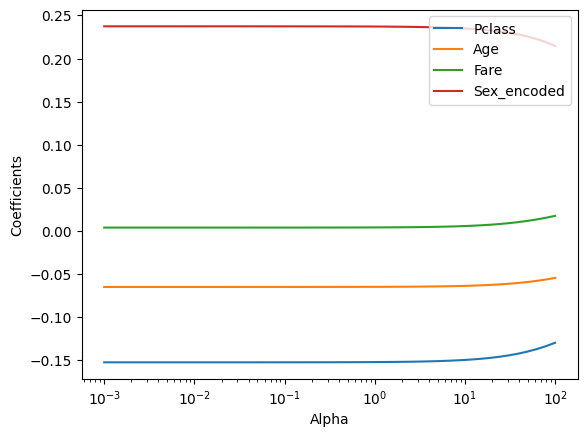

In [23]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(alphas,coef)
ax.set_xscale('log')
ax.set_xlabel("Alpha")
ax.set_ylabel("Coefficients")
ax.legend(features)
plt.show()

In [24]:
#Lasso
lasso_coef=[]
for a in alphas:
  clf_Lasso = Lasso(alpha=a)
  clf_Lasso.fit(X_scaled,y)
  lasso_coef.append(clf_Lasso.coef_)
lasso_coef=np.array(lasso_coef)

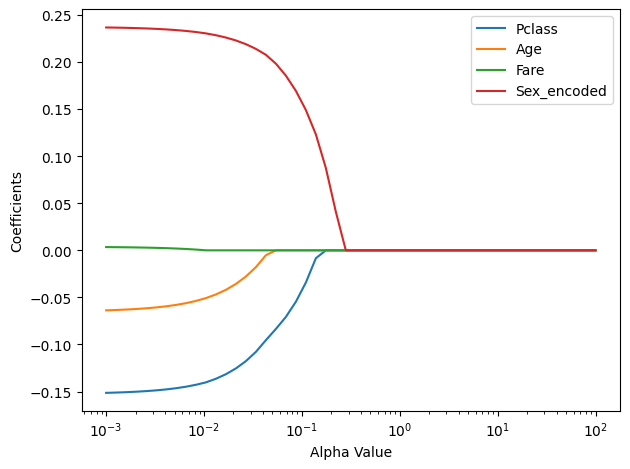

In [25]:
fig, ax = plt.subplots()
ax.plot(alphas,lasso_coef)

ax.set_xlabel("Alpha Value")
ax.set_ylabel("Coefficients")
ax.set_xscale('log')
ax.legend(features)
plt.tight_layout()
plt.show()

## Ridge (L2) v/s Lasso (L1)

1. Multicollinearity - Pclass and Fare are taken as redundant values by Lasso. Hence, Lasso makes fare 0 from the start. Other features start getting towards 0 depending upon the coefficients. Sex_encoded drops to 0 gradually around 0.5.

2. Ridge regularisation - coefficients never reach zero, even for features which may not be very influential like fare.

3. Sex_encoded survives longer before being taken down to zero. This confirms the analysis that gender was the strongest predictor for survival.

## Task 3 — Polynomial features + overfitting:
1. simple 1-feature data.
2. Fit degree 1, 2, 5, 10 using PolynomialFeatures + LinearRegression

In [26]:
from sklearn.datasets import  make_regression
X,y = make_regression(n_samples=50, n_features=1, noise=20, random_state= 42)

In [27]:
X.shape

(50, 1)

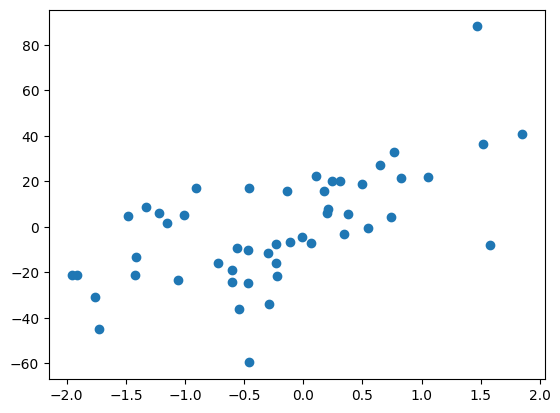

In [28]:
fig,ax = plt.subplots()
ax.scatter(X, y)

plt.show()

In [29]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

### What are the two separate transforms you need for polynomial features and why are they different?
1. Transform 1 (for fitting): Apply PolynomialFeatures to the original X (50 points) to create polynomial features, then fit LinearRegression on this transformed data.
2. Transform 2 (for plotting): Apply the same PolynomialFeatures degree to X_plot (300 evenly spaced points) to generate a smooth input range, then predict on it to produce a continuous curve.

In [30]:
#transforms X into polynomial features

# X_poly -> 300 points

X_poly_fit = PolynomialFeatures(degree=2).fit_transform(X)        # 50 points, for fitting
X_poly_plot = PolynomialFeatures(degree=2).fit_transform(X_plot)  # 300 points, for predicting/plotting

In [31]:
#fit linear regression on this transformed X_poly
fit = LinearRegression().fit(X_poly_fit,y)

In [32]:
#predict
predict_pol = fit.predict(X_poly_plot)

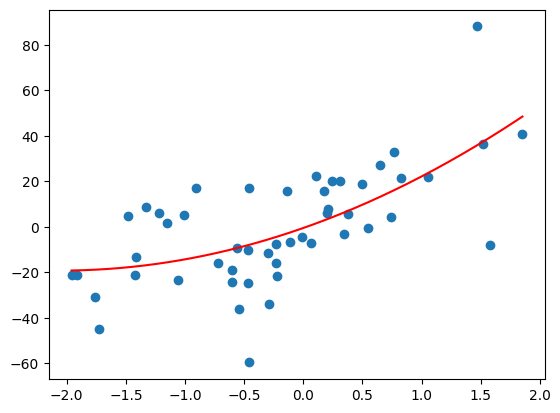

In [33]:
fig,ax = plt.subplots()
ax.scatter(X, y)
ax.plot(X_plot, predict_pol,c="red")
plt.show()

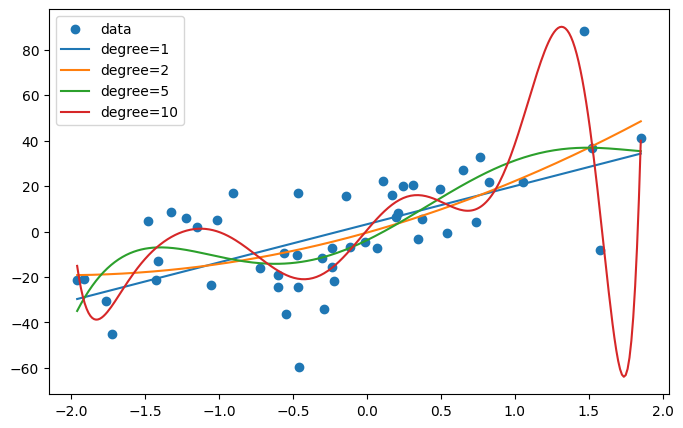

In [49]:
# degrees [1, 2, 5, 10]
degrees = [1, 2, 5, 10]

fig,ax = plt.subplots(figsize=(8,5))
#ax.scatter(X, y)
ax.scatter(X, y, label='data')
for a in degrees:
    X_poly_fit_transformed = PolynomialFeatures(degree=a).fit_transform(X)
    X_poly_degrees = PolynomialFeatures(degree= a).fit_transform(X_plot)

    fit_degrees = LinearRegression().fit(X_poly_fit_transformed,y)


    predict_pol_degrees = fit_degrees.predict(X_poly_degrees)
    ax.plot(X_plot, predict_pol_degrees, label=f'degree={a}')
ax.legend()
plt.show()

1. Degree 1 (blue) : straight line, underfitting, too simple
2. Degree 2 (orange) : smooth curve, fits the general trend well
3. Degree 5 (green) : starting to wiggle
4. Degree 10 (red) : completely wild at the edges, classic overfit

### Task 4 - Train vs Test MSE:
1. Split data with train_test_split.
2. For each degree, calculate MSE on both train and test set.
3. Plot degree on x-axis, MSE on y-axis, two lines (train and test).
- test MSE rise sharply at high degrees while train MSE keeps dropping --> that's the overfit signature.

In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#1,2,5,10
degrees = [1, 2, 5, 10]
train_mses = []
test_mses =[]

for a in degrees:
  X_train_transformed = PolynomialFeatures(degree=a).fit_transform(X_train)
  X_test_transformed = PolynomialFeatures(degree=a).fit_transform(X_test)

  #fit linear reg model
  Lin_model = LinearRegression().fit(X_train_transformed,y_train)

  #predict
  pred_train = Lin_model.predict(X_train_transformed)
  pred_test = Lin_model.predict(X_test_transformed)

  #Calculte MSE
  train_MSE = compute_mse(y_train,pred_train)
  test_MSE = compute_mse(y_test,pred_test)

  train_mses.append(train_MSE)
  test_mses.append(test_MSE)


In [57]:
train_mses

[np.float64(332.3418057164439),
 np.float64(321.218461070602),
 np.float64(286.18784495080746),
 np.float64(165.65220066091024)]

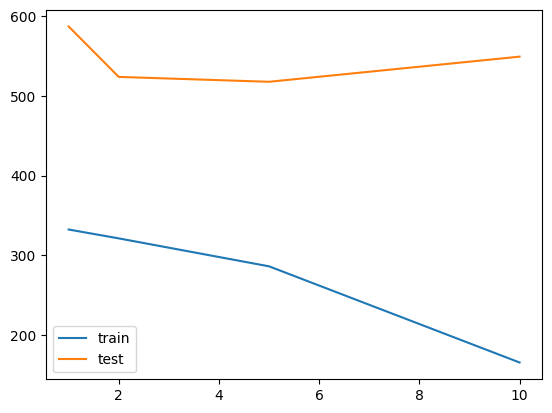

In [60]:
fig,ax = plt.subplots()
ax.plot(degrees, train_mses, label='train')
ax.plot(degrees, test_mses, label='test')
ax.legend()
plt.show()

### 1.Train MSE (blue) - keeps dropping as degree increases. Model fits training data better and better.
### 2. Test MSE (orange) - drops initially then rises at degree 10. Model stops generalising to new data.

    - That gap between blue and orange at degree 10 = overfitting.
    - The model memorised the training data instead of learning the pattern.